# Ejercicio

Construya el polinomio de Lagrange de máximo orden que
interpole los datos para aproximar f(0.45) = 1.204158 y calcule
el error absoluto

|xo=0 |  f(xo) = 1.00000|
|-----|-----------------|
|x1= 0.6| f(x1) = 1.264911|
|x20.9|  f(x2) = 1.378404|

In [5]:
import sympy as sp
import numpy as np
import modelos as m

x = sp.symbols('x')
x_data = np.array([0, 0.6, 0.9])
y_data = np.array([1.000, 1.264911, 1.378404])

def lagrange(x_data, y_data):
    sumPolinomio = 0
    for i in range(len(x_data)):
        Li = 1
        for j in range(len(x_data)):
            if j != i:
                Li *= (x-x_data[j]) / (x_data[i]-x_data[j])
        sumPolinomio += Li*y_data[i]
    return sp.expand(sumPolinomio)

P = lagrange(x_data, y_data)
print(P)
P2 = m.polinomial_simple(x_data, y_data)
print(P2)

-0.0702314814814802*x**2 + 0.483657222222222*x + 1.0
-0.070231481481481*x**2 + 0.483657222222222*x + 1.0


# Ejercicio 3



La tabla muestra cómo varía la densidad relativa $\\rho$ del aire con la altitud $h$. Determine la densidad relativa del aire a 1.5 km



|h(km)	| 0	|1.525	|3.050	|4.575	|6.10	|7.625	|9.150	|
|-------|-------|-------|-------|-------|-------|-------|-------|
|ρ	|1	|0.8617 |0.7385	|0.6292	|0.5238 |0.4481	|0.3741 |

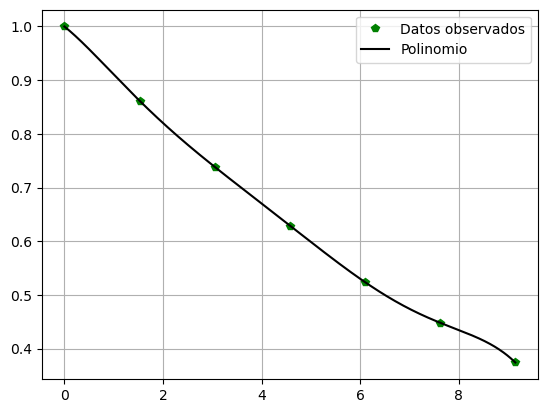

In [12]:
import matplotlib.pyplot as plt

x_h = np.array([0 ,1.525 ,3.050 ,4.575 ,6.10 ,7.625 ,9.150], float)
y_p = np.array([1, 0.8617, 0.7385, 0.6292, 0.5238, 0.4481, 0.3741], float)
P = m.lagrange(x_h, y_p)
P = sp.lambdify(x, P)
x_values = np.linspace(min(x_h), max(x_h), 500)
plt.plot(x_h, y_p, 'gp', label='Datos observados')
plt.plot(x_values, P(x_values), 'k', label='Polinomio')
plt.legend()
plt.grid()